# Rapport de projet – Analyse de données et apprentissage automatique

## Objectif général

Ce projet a pour objectif de conduire un pipeline complet d’analyse de données, depuis le choix du dataset jusqu’à l’application d’un ou plusieurs modèles de machine learning.Vous travaillerez en groupe (3 à 4 étudiants) et documenterez toutes les étapes de votre démarche dans ce rapport.Chaque section doit être remplie de manière rigoureuse, avec des explications claires et des justifications.Le rapport servira à l’évaluation finale du module pour **40 % de la note finale**.

# Partie 1 – Définition du sujet et choix du dataset

## 1.1 Thématique générale

**Domaine choisi :**  
Le projet s’inscrit dans le domaine de l’économie et de la finance, plus précisément dans l’analyse du risque de crédit.

**Problématique :**  
L’objectif de ce projet est d’analyser les caractéristiques financières et personnelles des emprunteurs afin de prédire le risque de défaut de paiement.  
La question centrale étudiée est la suivante :  
**Quels facteurs influencent le défaut de paiement et dans quelle mesure peut-on anticiper ce risque à partir des données disponibles ?**

**Intérêt du sujet :**  
L’évaluation du risque de crédit constitue un enjeu majeur pour les établissements financiers. Une mauvaise estimation du risque peut entraîner des pertes économiques importantes, tandis qu’une estimation trop stricte peut conduire à refuser l’accès au crédit à des emprunteurs pourtant solvables.

**Intérêt pour la société et les entreprises :**  
Ce sujet présente un intérêt à la fois économique et sociétal. Il permet d’améliorer la stabilité financière des institutions, de favoriser des décisions d’octroi de crédit plus justes et cohérentes, de limiter le surendettement des ménages et d’optimiser les politiques de gestion du risque.

## 1.2 Recherche et sélection du dataset

### Informations générales sur le dataset

**Nom du dataset :** Credit Risk Dataset  

**Source et lien d’accès :** Kaggle  https://www.kaggle.com/datasets/laotse/credit-risk-dataset

**Auteur / organisation :** Communauté Kaggle  

**Taille :** 32 581 lignes et 12 colonnes  

**Format du fichier :** CSV  

### Vérification de la qualité

Le dataset contient un volume de données suffisant pour réaliser une analyse statistique approfondie et entraîner des modèles de machine learning.  
Les variables sont clairement nommées et compréhensibles.  
Il comporte une variable cible binaire (`loan_status`) permettant d’identifier les situations de défaut de paiement.  
Certaines valeurs manquantes sont présentes, mais leur proportion reste limitée et traitable.

### Justification du choix

Ce dataset a été choisi car il est directement adapté à la problématique du risque de crédit. Il inclut des variables financières importantes (revenu, montant du prêt, taux d’intérêt), des informations sur les emprunteurs (âge, ancienneté d’emploi, historique de crédit) ainsi qu’une variable cible liée au défaut de paiement.

**Limites ou difficultés potentielles :** 

Le dataset présente des valeurs manquantes sur certaines variables, notamment l’ancienneté d’emploi et le taux d’intérêt.  
De plus, les données étant issues d’une source unique et anonymisées, des biais d’échantillonnage peuvent exister.

## 1.3 Validation du dataset

| Critère        | Question                                                                 | Réponse (Oui/Non) | Détail / Justification |
|---------------|--------------------------------------------------------------------------|-------------------|------------------------|
| Pertinence    | Le dataset permet-il de répondre à votre question de départ ?            | Oui               | Présence d’une variable cible liée au défaut de paiement |
| Clarté        | Les variables sont-elles bien nommées et compréhensibles ?               | Oui               | Noms explicites et cohérents avec le domaine du crédit |
| Propreté      | Les données semblent-elles utilisables sans nettoyage majeur ?           | Oui               | Valeurs manquantes présentes mais en proportion modérée |
| Taille        | Le dataset est-il d’une taille adaptée à votre analyse ?                 | Oui               | 32 581 observations, suffisant pour l’EDA et la modélisation |
| Accessibilité | Le format est-il compatible avec Python (CSV, XLSX) ?                    | Oui               | Format CSV directement lisible avec pandas |
| Actualité     | Les données sont-elles récentes ou encore valides ?                      | Oui               | Données réalistes et pertinentes pour une étude du risque |

# Partie 2 – Exploration initiale des données

## 2.1 Chargement et aperçu du dataset

In [92]:
import pandas as pd

PATH = 'credit_risk_dataset.csv'

df = pd.read_csv(PATH)

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**Dimensions du dataset :**

On affiche le nombre de lignes (observations) et de colonnes (variables).

In [93]:
df.shape

(32581, 12)

**Variables :** nom et type

On liste les variables et leurs types pandas (numérique / catégorielle).

In [94]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

**Signification de chaque variable :**

- **`person_age`** : âge du client (années)
- **`person_income`** : revenu annuel du client
- **`person_home_ownership`** : statut de logement (RENT / OWN / MORTGAGE / OTHER)
- **`person_emp_length`** : ancienneté professionnelle (années)
- **`loan_intent`** : objectif du prêt (EDUCATION, MEDICAL, PERSONAL, etc.)
- **`loan_grade`** : note de crédit du prêt (A → G, ordre de risque croissant)
- **`loan_amnt`** : montant du prêt
- **`loan_int_rate`** : taux d’intérêt du prêt
- **`loan_status`** : statut du prêt (cible) — **0 = non défaut, 1 = défaut**
- **`loan_percent_income`** : part du revenu consacrée au prêt (ratio)
- **`cb_person_default_on_file`** : défaut antérieur enregistré (Y / N)
- **`cb_person_cred_hist_length`** : durée de l’historique de crédit (années)

**Valeurs manquantes et incohérences :**

On calcule le nombre de valeurs manquantes par variable, puis le pourcentage par rapport au total.

In [95]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).sort_values('missing_count', ascending=False)

missing_report

,missing_count,missing_%
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


**Résultat attendu :**
- `person_emp_length` : **895** valeurs manquantes (~**2,75 %**)
- `loan_int_rate` : **3 116** valeurs manquantes (~**9,56 %**)
- Toutes les autres variables : **0** valeur manquante

**Contrôles simples d’incohérences :**
On vérifie des contraintes de bon sens (valeurs négatives, âges irréalistes, etc.).

In [96]:
# Contrôles de cohérence
checks = {
    'age_negative': (df['person_age'] < 0).sum(),
    'income_negative': (df['person_income'] < 0).sum(),
    'loan_amnt_negative': (df['loan_amnt'] < 0).sum(),
    'int_rate_negative': (df['loan_int_rate'] < 0).sum(),
    'emp_length_negative': (df['person_emp_length'] < 0).sum(),
    'loan_percent_income_negative': (df['loan_percent_income'] < 0).sum(),
    'cred_hist_negative': (df['cb_person_cred_hist_length'] < 0).sum(),
}

pd.Series(checks)

age_negative                    0
income_negative                 0
loan_amnt_negative              0
int_rate_negative               0
emp_length_negative             0
loan_percent_income_negative    0
cred_hist_negative              0
dtype: int64

**Interprétation :** si ces compteurs sont à 0, il n’y a pas d’incohérence évidente sur ces règles.
Les valeurs extrêmes (outliers) peuvent exister sans être des erreurs : elles seront traitées lors de l’analyse exploratoire.

## 2.2 Typologie des données

Classement des variables selon leur type (quantitative continue/discrète, qualitative nominale/ordinale, etc.).

#### Variables quantitatives continues
- `person_income`
- `person_emp_length`
- `loan_amnt`
- `loan_int_rate`
- `loan_percent_income`

#### Variables quantitatives discrètes
- `person_age`
- `cb_person_cred_hist_length`
- `loan_status` (binaire 0/1)

#### Variables qualitatives nominales
- `person_home_ownership`
- `loan_intent`
- `cb_person_default_on_file`

#### Variables qualitatives ordinales
- `loan_grade` (A → G)

#### Variables temporelles
- Aucune variable de type date/année n’est présente dans ce dataset.

#### Autres
- Aucune donnée non structurée (texte libre, image, etc.).


### Variables les plus importantes pour l’analyse (justification)
Dans une analyse de risque de crédit, les variables les plus importantes sont généralement celles qui reflètent :
1) la **capacité de remboursement**
2) le **profil de risque du prêt**
3) l’**historique de crédit**
4) la **stabilité**

#### 1) Capacité de remboursement
- `person_income`
- `loan_percent_income`
- `loan_amnt`

#### 2) Risque du prêt
- `loan_int_rate`
- `loan_grade`
- `loan_intent`

#### 3) Historique de crédit
- `cb_person_default_on_file`
- `cb_person_cred_hist_length`

#### 4) Stabilité / profil socio-démographique
- `person_emp_length`
- `person_home_ownership`
- `person_age`

On peut afficher des statistiques descriptives rapides :

In [97]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


### Variable cible
La variable cible (à prédire / expliquer) est **`loan_status`**.
- `0` : non défaut
- `1` : défaut

On peut vérifier la distribution de la cible :

In [98]:
df['loan_status'].value_counts(dropna=False).to_frame('count')

# En pourcentage
(df['loan_status'].value_counts(normalize=True) * 100).round(2).to_frame('pct')

,pct
loan_status,
0,78.18
1,21.82


# Partie 3 – Nettoyage et préparation du dataset

## 3.1 Gestion des valeurs manquantes

In [99]:
# Valeurs manquantes : nombre + pourcentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).sort_values('missing_count', ascending=False)

missing_report

,missing_count,missing_%
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


**Interprétation :**
Les valeurs manquantes concernent uniquement deux variables :

- `person_emp_length` : 895 valeurs manquantes (~2,75 %)
- `loan_int_rate` : 3 116 valeurs manquantes (~9,56 %)

Toutes les autres variables ne présentent aucune valeur manquante.

**Stratégie appliquée :**  
Imputation par la médiane pour les variables numériques.

**Justification :**  
La proportion de valeurs manquantes est modérée ; supprimer les lignes ferait perdre de l’information.  
La médiane est robuste face aux valeurs extrêmes, fréquentes dans les données financières.

In [100]:
# Imputation par la médiane
df_clean = df.copy()

df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

# Vérification
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## 3.2 Détection et traitement des doublons

In [101]:
# Détection des doublons
df_clean.duplicated().sum()

165

**Interprétation :**
165 doublons ont été détectés avant traitement.

In [102]:
# Suppression des doublons
df_clean = df_clean.drop_duplicates()

df_clean.shape

(32416, 12)

Ils ont été supprimés afin d’éviter une sur-représentation artificielle de certaines observations, pouvant biaiser les statistiques et les modèles.

## 3.3 Détection des valeurs aberrantes

In [103]:
import numpy as np

# Colonnes numériques (incluant la cible pour l'instant)
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

# Détection via IQR
outlier_summary = []

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    
    outliers = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    outlier_summary.append((col, int(outliers), low, high))

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["variable", "n_outliers", "low_bound", "high_bound"]
).sort_values("n_outliers", ascending=False)

outlier_df


,variable,n_outliers,low_bound,high_bound
5,loan_status,7089,0.00,0.00
3,loan_amnt,1679,-5875.00,23125.00
0,person_age,1491,12.50,40.50
1,person_income,1478,-22472.00,140232.00
7,cb_person_cred_hist_length,1139,-4.50,15.50
2,person_emp_length,852,-5.50,14.50
6,loan_percent_income,650,-0.12,0.44
4,loan_int_rate,70,1.56,20.04


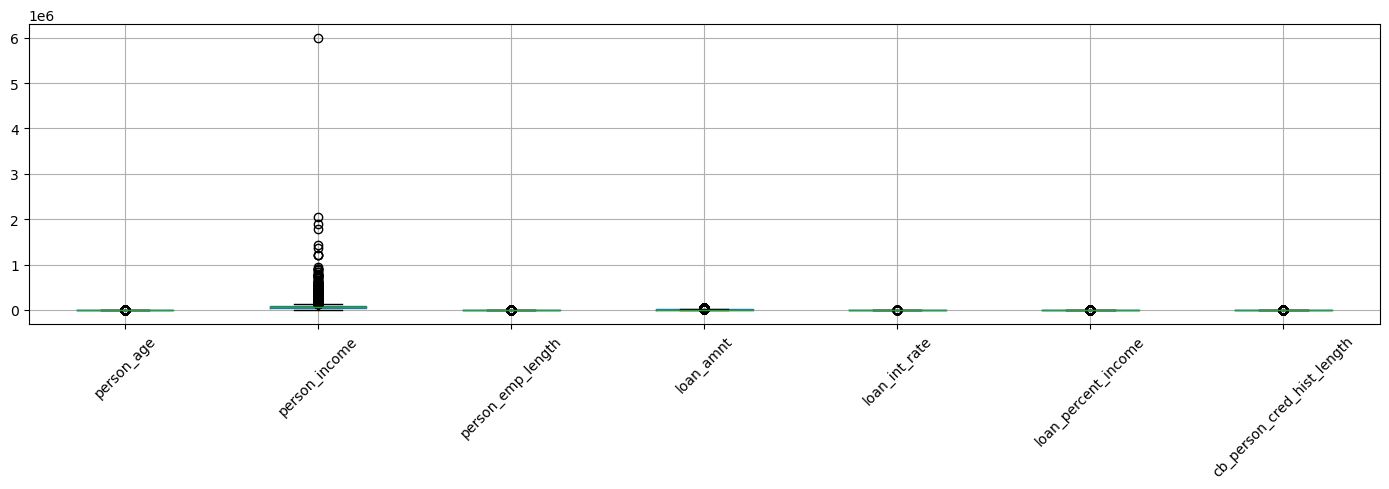

In [104]:
import matplotlib.pyplot as plt

numeric_cols_no_target = [col for col in numeric_cols if col != "loan_status"]

plt.figure(figsize=(14, 5))
df_clean[numeric_cols_no_target].boxplot(rot=45)
plt.tight_layout()
plt.show()

La méthode IQR met en évidence des valeurs extrêmes sur plusieurs variables numériques (revenu, montant de prêt, taux d’intérêt, ratio prêt/revenu).  
Dans un contexte de crédit, ces valeurs peuvent correspondre à des profils rares mais réalistes (revenus élevés, prêts importants).

**Décision :**  
Les valeurs extrêmes ont été conservées, car elles peuvent contenir une information pertinente pour la modélisation. Une limitation (winsorisation/capping) pourrait être testée ultérieurement à titre comparatif.

## 3.4 Encodage et mise à l’échelle des variables

Certaines variables doivent être converties en numériques avant d’être utilisées dans un modèle.

Dans cette section, on prépare les données en :
- standardisant les variables numériques (centrage-réduction) ;
- encodant les variables catégorielles par One-Hot Encoding.

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Séparation features / cible
X = df_clean.drop(columns=["loan_status"]) # df_clean doit exister (après nettoyage)
y = df_clean["loan_status"]


# Identification automatique des colonnes numériques et catégorielles
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


numeric_features, categorical_features

(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'])

**Variables concernées :**

- **Variables numériques (standardisées)** : `person_age`, `person_income`, `person_emp_length`, `loan_amnt`, `loan_int_rate`, `loan_percent_income`, `cb_person_cred_hist_length`
- **Variables catégorielles (encodées)** : `person_home_ownership`, `loan_intent`, `loan_grade`, `cb_person_default_on_file`

In [106]:
# Construction du prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Aperçu après encodage

Afin de visualiser concrètement le résultat du prétraitement, on applique la transformation à `X` puis on reconstruit un DataFrame avec les noms des nouvelles colonnes.

In [107]:
# Fit + transformation
X_encoded = preprocessor.fit_transform(X)

# Récupération des noms de colonnes One-Hot
num_features_out = numeric_features
cat_features_out = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = list(num_features_out) + list(cat_features_out)

# Conversion en DataFrame lisible (attention mémoire si dataset très grand)
X_encoded_df = pd.DataFrame(
X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded,
columns=feature_names
)

# Aperçu
X_encoded_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,-0.904471,-0.114354,28.904903,4.018287,1.623527,3.929865,-0.692614,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-1.061852,-0.910941,0.056504,-1.359219,0.040655,-0.657707,-0.938982,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.432327,-0.910941,-0.921408,-0.647491,0.601796,3.742617,-0.692614,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.747089,-0.009540,-0.187974,4.018287,1.367283,3.368121,-0.938982,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.589708,-0.188530,0.789938,4.018287,1.055898,3.555369,-0.446246,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [108]:
# Dimensions avant / après encodage
print("Dimensions avant encodage :", X.shape)
print("Dimensions après encodage :", X_encoded_df.shape)

Dimensions avant encodage : (32416, 11)
Dimensions après encodage : (32416, 26)


**Interprétation :**

Après application du prétraitement, toutes les variables sont numériques, ce qui permet l’entraînement des modèles de machine learning.

- Les variables numériques ont été **standardisées** : elles sont centrées autour de 0 avec une variance proche de 1.  
  Cela évite qu’une variable à grande échelle (ex. revenu, montant du prêt) domine l’apprentissage.

- Les variables catégorielles ont été transformées via **One-Hot Encoding** : chaque modalité devient une colonne binaire (0/1).  
  Bien que `loan_grade` possède un ordre naturel (A → G), le One-Hot Encoding permet de ne pas imposer une relation linéaire artificielle entre les grades.

**Pourquoi standardiser :**  
Certains modèles (régression logistique, SVM, kNN) sont sensibles à l’échelle des variables. Sans standardisation, les variables ayant de grandes valeurs peuvent biaiser l’entraînement et la performance du modèle.

Le dataset est désormais nettoyé et prêt pour l’analyse exploratoire et la modélisation.

# Partie 4 – Analyse exploratoire et visualisations

Réalisez une première exploration visuelle pour mieux comprendre les relations entre les variables.

In [109]:
# Corrélation entre variables numériques
corr = df_clean.select_dtypes(include=["int64", "float64"]).corr()

corr

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173293,0.161342,0.050680,0.011074,-0.022698,-0.042300,0.859215
person_income,0.173293,1.000000,0.134791,0.265947,0.000826,-0.145005,-0.254472,0.117614
person_emp_length,0.161342,0.134791,1.000000,0.113934,-0.051462,-0.082517,-0.054024,0.143251
loan_amnt,0.050680,0.265947,0.113934,1.000000,0.139596,0.105736,0.572824,0.041865
loan_int_rate,0.011074,0.000826,-0.051462,0.139596,1.000000,0.320081,0.114411,0.015000
loan_status,-0.022698,-0.145005,-0.082517,0.105736,0.320081,1.000000,0.379697,-0.016498
loan_percent_income,-0.042300,-0.254472,-0.054024,0.572824,0.114411,0.379697,1.000000,-0.031457
cb_person_cred_hist_length,0.859215,0.117614,0.143251,0.041865,0.015000,-0.016498,-0.031457,1.000000


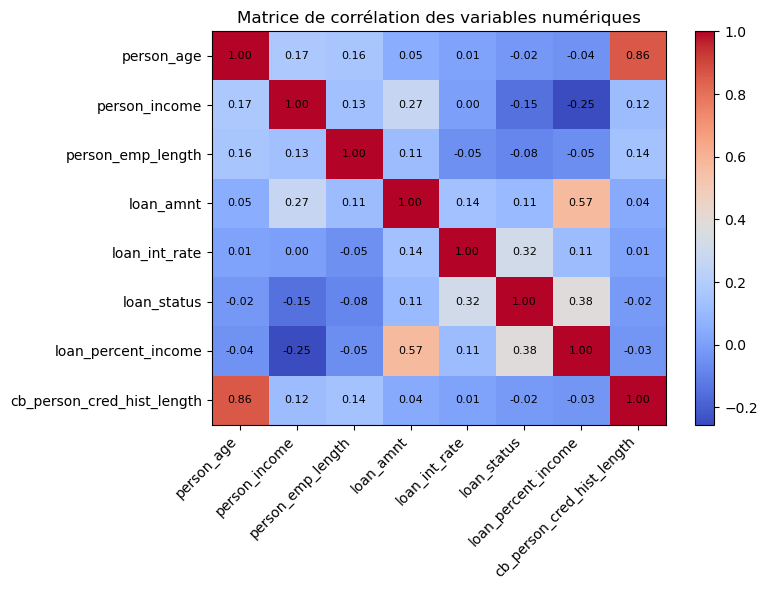

In [110]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

**Interprétation :**

L’analyse de la matrice de corrélation met en évidence plusieurs relations intéressantes entre les variables numériques.

On observe notamment une corrélation positive entre :
- le montant du prêt (`loan_amnt`) et le ratio prêt / revenu (`loan_percent_income`), ce qui est cohérent puisque des prêts plus élevés représentent généralement une part plus importante du revenu ;
- le revenu (`person_income`) et le montant du prêt (`loan_amnt`), suggérant que les emprunteurs disposant de revenus plus élevés peuvent accéder à des montants de prêt plus importants.

Concernant la variable cible (`loan_status`), les corrélations linéaires restent globalement modérées. Cela indique que le défaut de paiement n’est pas expliqué par une seule variable prise isolément, mais résulte probablement de la combinaison de plusieurs facteurs financiers et personnels.

Enfin, aucune corrélation extrêmement forte n’est observée entre les variables explicatives, ce qui limite les risques de multicolinéarité dans les modèles.

#### Quelles variables semblent influencer la variable cible ?

Ici, on va comparer la variable cible (loan_status) avec des variables clés, à l’aide de graphiques simples et parlants.

### Distribution de la variable cible

In [111]:
# Distribution de la variable cible
df_clean["loan_status"].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

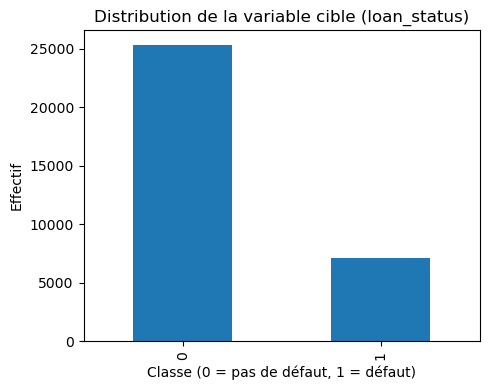

In [112]:
plt.figure(figsize=(5,4))
df_clean["loan_status"].value_counts().plot(kind="bar")
plt.title("Distribution de la variable cible (loan_status)")
plt.xlabel("Classe (0 = pas de défaut, 1 = défaut)")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

### Variable financière clé : ratio prêt / revenu

<Figure size 600x400 with 0 Axes>

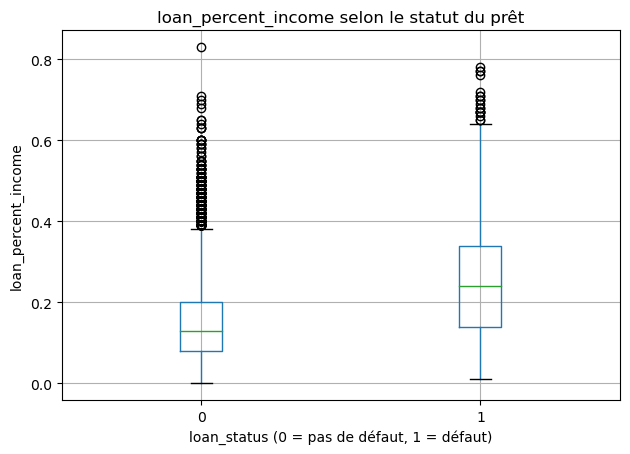

In [113]:
plt.figure(figsize=(6,4))
df_clean.boxplot(column="loan_percent_income", by="loan_status")
plt.suptitle("")
plt.title("loan_percent_income selon le statut du prêt")
plt.xlabel("loan_status (0 = pas de défaut, 1 = défaut)")
plt.ylabel("loan_percent_income")
plt.tight_layout()
plt.show()

### Variable financière clé : taux d’intérêt

<Figure size 600x400 with 0 Axes>

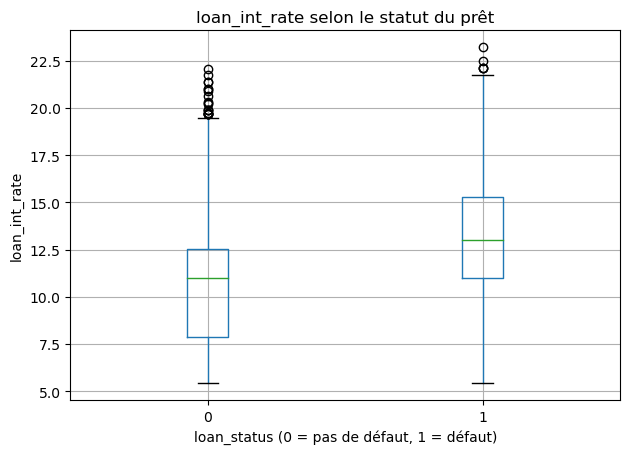

In [114]:
plt.figure(figsize=(6,4))
df_clean.boxplot(column="loan_int_rate", by="loan_status")
plt.suptitle("")
plt.title("loan_int_rate selon le statut du prêt")
plt.xlabel("loan_status (0 = pas de défaut, 1 = défaut)")
plt.ylabel("loan_int_rate")
plt.tight_layout()
plt.show()

**Interprétation :**

L’analyse des graphiques met en évidence plusieurs variables semblant influencer la variable cible `loan_status`.

Le ratio prêt / revenu (`loan_percent_income`) apparaît comme un facteur important. Les emprunteurs en situation de défaut présentent en moyenne un ratio plus élevé, ce qui indique qu’une part plus importante de leur revenu est consacrée au remboursement du prêt. Cela suggère une capacité de remboursement plus fragile.

Le taux d’intérêt (`loan_int_rate`) est également plus élevé pour les prêts en défaut. Un taux élevé peut refléter un profil de risque plus important ou des conditions de prêt moins favorables, ce qui augmente la probabilité de défaut.

Ces observations montrent que les variables financières directement liées au coût du crédit et à la capacité de remboursement jouent un rôle clé dans l’apparition des défauts de paiement.

**Hypothèses :**

À partir des analyses exploratoires et des visualisations réalisées, plusieurs hypothèses peuvent être formulées concernant le risque de défaut de paiement.

Premièrement, plus le ratio prêt / revenu (`loan_percent_income`) est élevé, plus le risque de défaut augmente. Une part trop importante du revenu consacrée au remboursement du prêt peut fragiliser la capacité financière de l’emprunteur.

Deuxièmement, un taux d’intérêt plus élevé (`loan_int_rate`) semble associé à une probabilité plus forte de défaut. Cela peut refléter un profil de risque initialement jugé plus élevé par l’organisme prêteur ou des conditions de crédit moins favorables.

Troisièmement, les caractéristiques liées à l’historique de crédit pourraient jouer un rôle important. Les emprunteurs ayant déjà connu un défaut (`cb_person_default_on_file = Y`) ou disposant d’un historique de crédit plus court (`cb_person_cred_hist_length`) pourraient présenter un risque accru.

Enfin, la qualité du prêt, représentée par la variable `loan_grade`, est susceptible d’influencer le défaut : des grades moins favorables (par exemple E, F ou G) devraient être associés à une probabilité de défaut plus élevée que les grades les plus élevés (A ou B).

Ces hypothèses seront testées et approfondies lors de la phase de modélisation.

**Analyse des graphiques :**

Les graphiques exploratoires mettent en évidence plusieurs tendances générales dans les données.

On observe tout d’abord une forte asymétrie dans la distribution de certaines variables financières, notamment le revenu annuel (`person_income`) et le montant du prêt (`loan_amnt`). La majorité des emprunteurs se concentre sur des valeurs relativement modestes, tandis que quelques observations présentent des valeurs très élevées.

Les boxplots montrent également une séparation partielle entre les classes de la variable cible. Les emprunteurs en défaut présentent, en moyenne, des valeurs plus élevées pour le ratio prêt / revenu et pour le taux d’intérêt, même si un chevauchement important subsiste entre les deux groupes.

Enfin, les relations observées suggèrent que le défaut de paiement n’est pas déterminé par un seul facteur isolé, mais résulte d’une combinaison de variables financières, de caractéristiques du prêt et d’éléments liés à l’historique de crédit.

Ces patterns confirment la pertinence d’utiliser des modèles de machine learning capables de capturer des interactions entre plusieurs variables plutôt qu’une règle simple basée sur un seuil unique.

L’analyse exploratoire met en évidence plusieurs variables clés influençant le risque de défaut. Ces résultats justifient l’utilisation de modèles de machine learning afin de capturer les interactions complexes entre les variables et prédire efficacement la variable cible.